In this Data Science Project we will create a Linear Regression model and a Decision Tree Regression Model to Predict Apple’s Stock Price using Machine Learning and Python.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('AAPL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2021-09-15,148.559998,149.440002,146.369995,149.029999,148.812805,83281300
1,2021-09-16,148.440002,148.970001,147.220001,148.789993,148.573151,68034100
2,2021-09-17,148.820007,148.820007,145.759995,146.059998,145.847137,129868800
3,2021-09-20,143.800003,144.839996,141.270004,142.940002,142.731689,123478900
4,2021-09-21,143.929993,144.600006,142.779999,143.429993,143.220963,75834000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       64 non-null     object 
 1   Open       64 non-null     float64
 2   High       64 non-null     float64
 3   Low        64 non-null     float64
 4   Close      64 non-null     float64
 5   Adj Close  64 non-null     float64
 6   Volume     64 non-null     int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 3.6+ KB


In [6]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,64.000000,64.000000,64.000000,64.000000,64.000000,6.400000e+01
mean,151.835469,153.575000,150.565624,152.245313,152.122357,8.665402e+07
std,9.854719,10.432444,9.599117,10.008503,10.086403,2.996008e+07
min,139.470001,141.399994,138.270004,139.139999,138.937225,4.100000e+07
25%,144.004998,145.695004,143.422497,145.237495,145.025837,6.315762e+07
50%,148.975006,150.035004,147.994995,149.290001,149.072441,7.639160e+07
75%,157.922497,160.592499,156.402501,158.462497,158.462497,1.089358e+08
max,181.119995,182.130005,175.529999,179.449997,179.449997,1.740481e+08


In [11]:
print("trainging days =",df.shape)

trainging days = (64, 7)


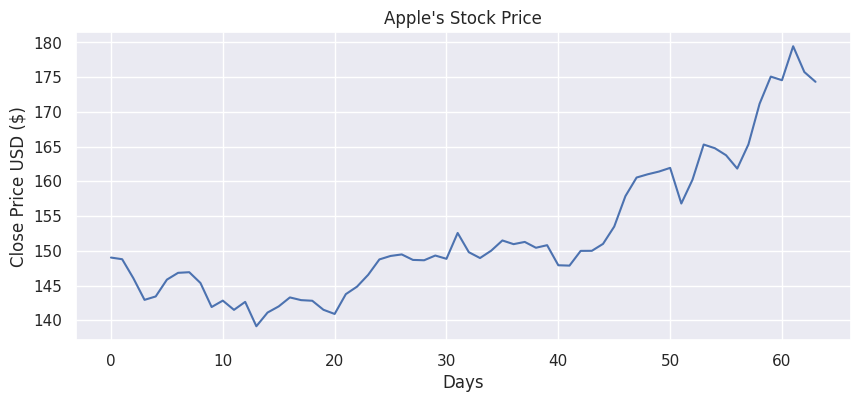

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
plt.figure(figsize=(10, 4))
plt.title("Apple's Stock Price")
plt.xlabel("Days")
plt.ylabel("Close Price USD ($)")
plt.plot(df["Close"])
plt.show()

In [16]:
futureDays = 25

In [19]:
df['Prediction'] = df['Close'].shift(-futureDays)

In [20]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,Prediction
59,2021-12-08,172.130005,175.960007,170.699997,175.080002,175.080002,116998900,NaN
60,2021-12-09,174.910004,176.750000,173.919998,174.559998,174.559998,108923700,NaN
61,2021-12-10,175.210007,179.630005,174.690002,179.449997,179.449997,115228100,NaN
62,2021-12-13,181.119995,182.130005,175.529999,175.740005,175.740005,153237000,NaN
63,2021-12-14,175.250000,177.740005,172.210007,174.330002,174.330002,139285700,NaN


In [22]:
import numpy as np
x = np.array(df.drop("Prediction", axis=1))[:-futureDays]
print(x)

[['2021-09-15' 148.559998 149.440002 146.369995 149.029999 148.812805
  83281300]
 ['2021-09-16' 148.440002 148.970001 147.220001 148.789993 148.573151
  68034100]
 ['2021-09-17' 148.820007 148.820007 145.759995 146.059998 145.847137
  129868800]
 ['2021-09-20' 143.800003 144.839996 141.270004 142.940002 142.731689
  123478900]
 ['2021-09-21' 143.929993 144.600006 142.779999 143.429993 143.220963
  75834000]
 ['2021-09-22' 144.449997 146.429993 143.699997 145.850006 145.637451
  76404300]
 ['2021-09-23' 146.649994 147.080002 145.639999 146.830002 146.616028
  64838200]
 ['2021-09-24' 145.660004 147.470001 145.559998 146.919998 146.705887
  53477900]
 ['2021-09-27' 145.470001 145.960007 143.820007 145.369995 145.158142
  74150700]
 ['2021-09-28' 143.25 144.75 141.690002 141.910004 141.703186 108972300]
 ['2021-09-29' 142.470001 144.449997 142.029999 142.830002 142.621857
  74602000]
 ['2021-09-30' 143.660004 144.380005 141.279999 141.5 141.293793 88934200]
 ['2021-10-01' 141.899994 142.

In [23]:
y = np.array(df["Prediction"])[:-futureDays]
print(y)

[149.259995 149.479996 148.690002 148.639999 149.320007 148.850006
 152.570007 149.800003 148.960007 150.020004 151.490005 150.960007
 151.279999 150.440002 150.809998 147.919998 147.869995 149.990005
 150.       151.       153.490005 157.869995 160.550003 161.020004
 161.410004 161.940002 156.809998 160.240005 165.300003 164.770004
 163.759995 161.839996 165.320007 171.179993 175.080002 174.559998
 179.449997 175.740005 174.330002]


In [24]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [38]:
from sklearn.tree import DecisionTreeRegressor
# Remove the 'Date' column (first column) from x_train as it's a string
x_train_numerical = x_train[:, 1:]
tree = DecisionTreeRegressor().fit(x_train_numerical, y_train)

In [27]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(x_train_numerical, y_train)
#

In [39]:
xfuture=df.drop(['Prediction'],axis=1)[:-futureDays]
xfuture=xfuture.tail(futureDays)
xfuture=np.array(xfuture)
xfuture=xfuture[:,1:]
print(xfuture[:5])

[[139.490005 142.240005 139.360001 141.110001 140.904358 80861100]
 [139.470001 142.149994 138.369995 142.0 141.79306 83221100]
 [143.059998 144.220001 142.720001 143.289993 143.081177 61732700]
 [144.029999 144.179993 142.559998 142.899994 142.691742 58718700]
 [142.270004 144.809998 141.809998 142.809998 142.601883 64452200]]


In [30]:
treePrediction = tree.predict(xfuture)
print("Decision Tree prediction =",treePrediction)

Decision Tree prediction = [150.809998 147.919998 147.869995 149.990005 150.       151.
 153.490005 157.869995 160.550003 161.020004 161.410004 161.940002
 161.940002 161.410004 165.300003 164.770004 161.410004 161.839996
 165.320007 161.410004 175.080002 174.559998 175.740005 175.740005
 174.330002]


In [32]:
linearPrediction = lr.predict(xfuture)
print("Linear regression Prediction =",linearPrediction)

Linear regression Prediction = [151.30186274 150.78228621 153.09513066 150.85680557 154.93309791
 147.75617158 145.75337416 153.20738357 154.22750616 158.8549529
 160.91844623 161.17325563 160.47412216 160.13023078 160.10305325
 162.82964443 159.95060405 167.06882926 159.92033001 159.15414333
 165.47343788 165.30520877 163.85261157 175.17902663 174.89543854]


/tmp/ipython-input-518721929.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid["Predictions"] = predictions


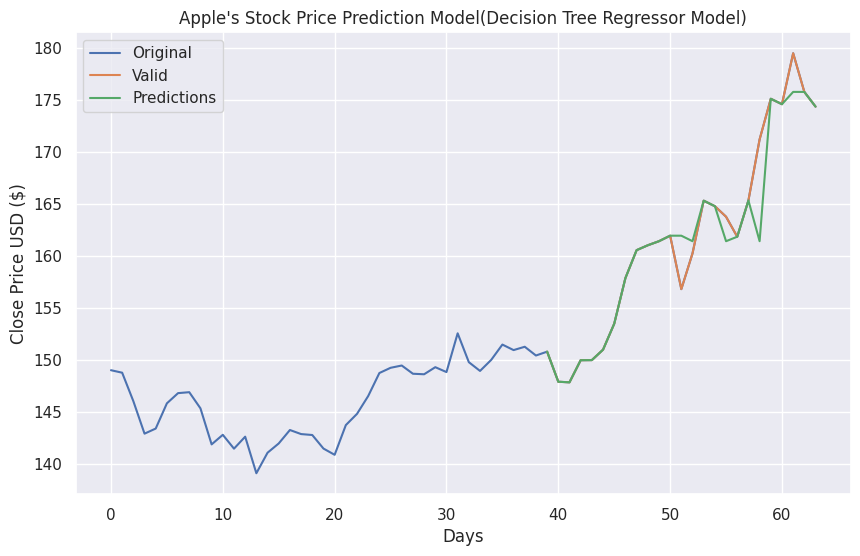

In [37]:
predictions = treePrediction
valid = df[x.shape[0]:]
valid["Predictions"] = predictions
plt.figure(figsize=(10, 6))
plt.title("Apple's Stock Price Prediction Model(Decision Tree Regressor Model)")
plt.xlabel("Days")
plt.ylabel("Close Price USD ($)")
plt.plot(df["Close"])
plt.plot(valid[["Close", "Predictions"]])
plt.legend(["Original", "Valid", "Predictions"])
plt.show()

/tmp/ipython-input-119189666.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid["Predictions"] = predictions


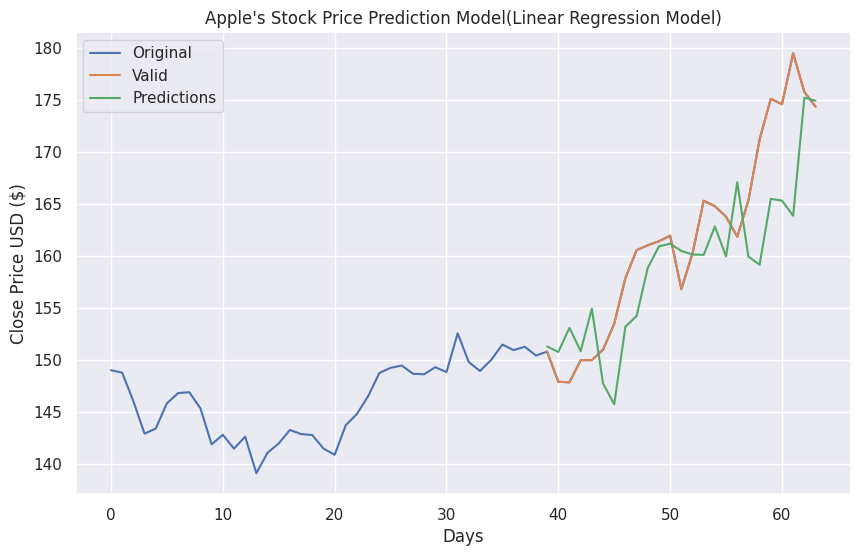

In [36]:
predictions = linearPrediction
valid = df[x.shape[0]:]
valid["Predictions"] = predictions
plt.figure(figsize=(10, 6))
plt.title("Apple's Stock Price Prediction Model(Linear Regression Model)")
plt.xlabel("Days")
plt.ylabel("Close Price USD ($)")
plt.plot(df["Close"])
plt.plot(valid[["Close", "Predictions"]])
plt.legend(["Original", "Valid", "Predictions"])
plt.show()

In [40]:
import joblib

# Save the Decision Tree Regressor model
joblib.dump(tree, 'decision_tree_model.joblib')
print("Decision Tree model saved as 'decision_tree_model.joblib'")

# Save the Linear Regression model
joblib.dump(lr, 'linear_regression_model.joblib')
print("Linear Regression model saved as 'linear_regression_model.joblib'")

Decision Tree model saved as 'decision_tree_model.joblib'
Linear Regression model saved as 'linear_regression_model.joblib'


In [41]:
# Example of loading a model back
loaded_tree_model = joblib.load('decision_tree_model.joblib')
print(f"Loaded Decision Tree model: {loaded_tree_model}")

Loaded Decision Tree model: DecisionTreeRegressor()
